In [5]:
import sys
!{sys.executable} -m pip install pyarrow


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import sys
!{sys.executable} -m pip install deltalake pandas matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from deltalake import DeltaTable
import os

# Verinin yolunu buluyoruz
current_dir = os.getcwd()
data_path = os.path.abspath(os.path.join(current_dir, "..", "data", "gold"))

# Delta tablosunu Pandas'a çevirerek okuyoruz
dt = DeltaTable(data_path)
df = dt.to_pandas()

print("Veri Başarıyla Okundu!\n")
print("-" * 30)

print(f"Toplam Satır Sayısı: {len(df)}") 
print(f"Toplam Sütun Sayısı: {len(df.columns)}\n")

print("Veri Setinin Şeması ve Veri Tipleri:")
print(df.info())

print("\nİlk 5 Satır:")
display(df.head())

Veri Başarıyla Okundu!

------------------------------
Toplam Satır Sayısı: 17432
Toplam Sütun Sayısı: 16

Veri Setinin Şeması ve Veri Tipleri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17432 entries, 0 to 17431
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   timestamp                   17432 non-null  datetime64[us, UTC]
 1   user_id                     17432 non-null  int32              
 2   event_type                  17432 non-null  object             
 3   related_id                  17432 non-null  object             
 4   iso_code                    17432 non-null  object             
 5   country                     17432 non-null  object             
 6   year                        17432 non-null  float64            
 7   primary_energy_consumption  17432 non-null  float64            
 8   fossil_fuel_consumption     17432 non-null  float64 

,timestamp,user_id,event_type,related_id,iso_code,country,year,primary_energy_consumption,fossil_fuel_consumption,renewables_consumption,carbon_intensity_elec,is_weekend,time_of_day,user_event_count,item_popularity,event_risk_score
0,2026-04-11 06:09:18.251362+00:00,2,Normal Kapanış,LBY-2016,LBY,Libya,2016.0,211.483,0.000,0.000,0.0,1,Sabah,348,1,1
1,2026-04-27 16:21:18.262107+00:00,6,Enerji Tüketimi,ESP-1983,ESP,Spain,1983.0,909.258,802.958,76.686,0.0,0,Öğle,345,1,2
2,2026-05-06 14:35:18.272849+00:00,23,Aşırı Yüklenme,ALB-1987,ALB,Albania,1987.0,56.775,0.000,0.000,0.0,0,Öğle,341,1,4
3,2026-04-12 12:21:18.283480+00:00,40,Cihaz Arızası,nan-1983,"""NaN""",USSR,1983.0,14338.147,0.000,0.000,0.0,1,Öğle,374,26,5
4,2026-04-30 16:55:18.294155+00:00,18,Sistem Uyarısı,MYS-1947,MYS,Malaysia,1947.0,0.000,0.000,0.000,0.0,0,Öğle,370,1,3


--- RELATED_ID (İLGİLİ ÖĞE) ANALİZİ ---


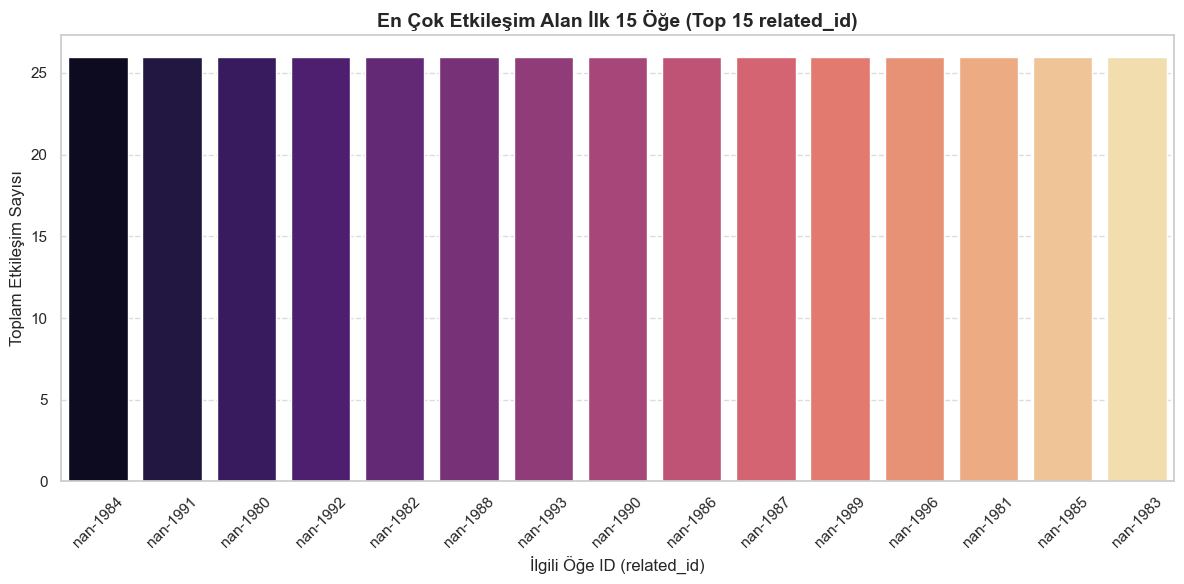

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- RELATED_ID (İLGİLİ ÖĞE) ANALİZİ ---")

# 15 bin farklı öğe olduğu için, sadece en çok etkileşim alan ilk 15 tanesini buluyoruz
top_15_related = df['related_id'].value_counts().head(15)

# Dağılım Grafiği (Bar Chart)
plt.figure(figsize=(12, 6))

# hue ve legend=False parametreleri Seaborn'un yeni sürümlerinde hata vermemesi için eklendi
sns.barplot(x=top_15_related.index, 
            y=top_15_related.values, 
            hue=top_15_related.index, 
            palette='magma', 
            legend=False)

plt.title('En Çok Etkileşim Alan İlk 15 Öğe (Top 15 related_id)', fontsize=14, fontweight='bold')
plt.xlabel('İlgili Öğe ID (related_id)', fontsize=12)
plt.ylabel('Toplam Etkileşim Sayısı', fontsize=12)

# ID numaraları uzun olabileceği için yazıları 45 derece eğik yazdırıyoruz
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1. 'data' sütunundaki gizli veriler paketinden çıkarılıyor...
Paketten Toplam 7 Yeni Sütun Çıktı.
------------------------------
Toplam 4 adet sayısal değişken bulundu. Tüm grafikler sırasıyla çiziliyor...



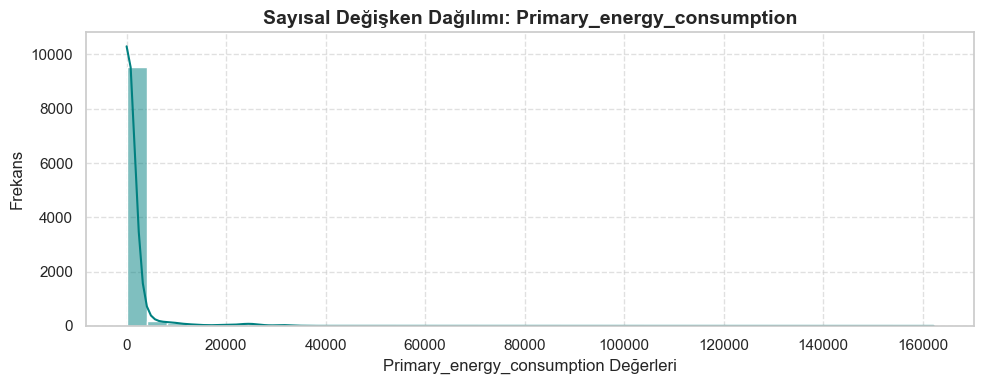

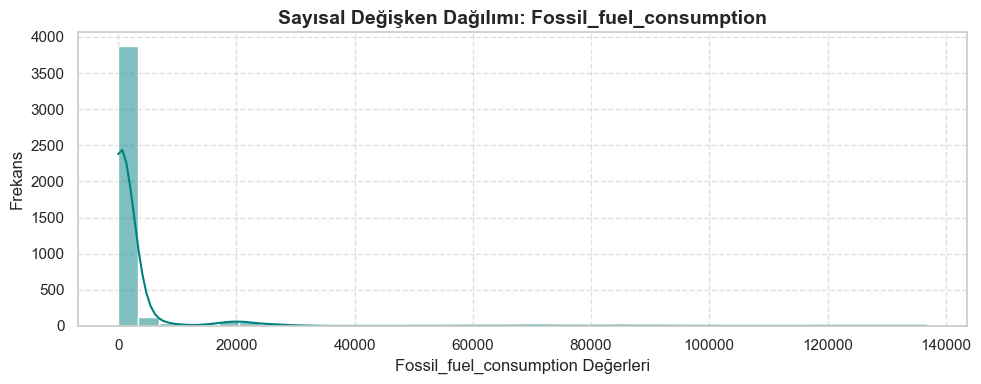

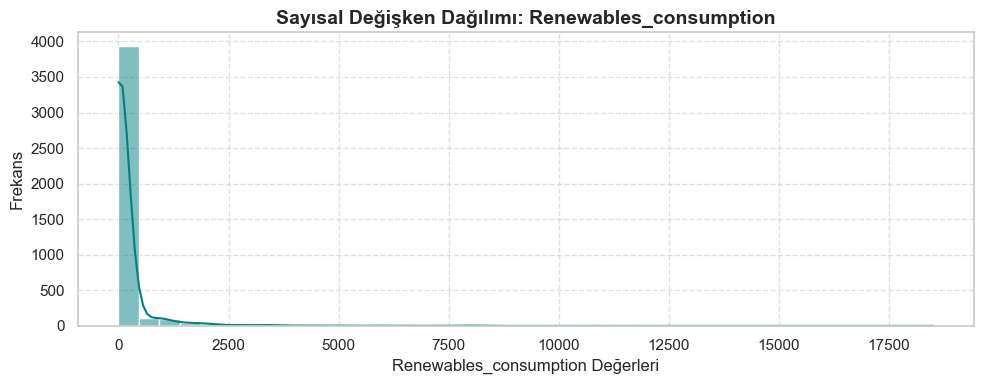

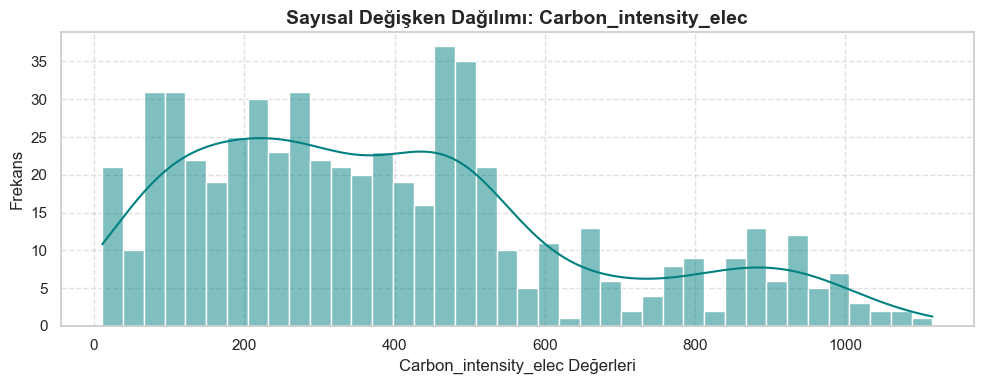

In [11]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("1. 'data' sütunundaki gizli veriler paketinden çıkarılıyor...")

def veri_ayikla(val):
    try:
        if isinstance(val, dict):
            return val
        return ast.literal_eval(str(val))
    except:
        return {}

# Veriyi çözüp yeni sütunlar (tablo) haline getiriyoruz
ayiklanan_veri = df['data'].apply(veri_ayikla).apply(pd.Series)

# Çözülen veriyi ana tablomuza ekliyoruz
df_son = pd.concat([df.drop('data', axis=1), ayiklanan_veri], axis=1)

print(f"Paketten Toplam {len(ayiklanan_veri.columns)} Yeni Sütun Çıktı.")
print("-" * 30)

# 'year' (yıl) haricindeki tüm gerçek sayısal sütunları buluyoruz
sayisal_sutunlar = ayiklanan_veri.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'year' in sayisal_sutunlar:
    sayisal_sutunlar.remove('year')

if len(sayisal_sutunlar) > 0:
    print(f"Toplam {len(sayisal_sutunlar)} adet sayısal değişken bulundu. Tüm grafikler sırasıyla çiziliyor...\n")
    
    # Bulunan tüm sayısal sütunlar için bir döngü başlatıyoruz
    for hedef in sayisal_sutunlar:
        plt.figure(figsize=(10, 4))
        # Dağılımı Histogram ve yoğunluk çizgisi (KDE) ile görselleştiriyoruz
        sns.histplot(data=df_son, x=hedef, bins=40, kde=True, color='teal')
        
        plt.title(f'Sayısal Değişken Dağılımı: {hedef.capitalize()}', fontsize=14, fontweight='bold')
        plt.xlabel(hedef.capitalize() + ' Değerleri', fontsize=12)
        plt.ylabel('Frekans', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
else:
    print("Sayısal bir sütun bulunamadı, paket içeriği sadece metinlerden oluşuyor.")

🥇 1. GOLD Veri Okunuyor...
🧹 2. Son Temizlik Kontrolü (Güvenlik Ağı Devrede)...

--- EKSİK (NULL) DEĞER ANALİZİ ---
✅ Harika! Veri setinde tek bir eksik değer bile yok. Gold katman kusursuz.

--- 📊 KEŞİFSEL VERİ ANALİZİ (EDA) EKRANI HAZIRLANIYOR ---


C:\Users\tahab\AppData\Local\Temp\ipykernel_7460\985699610.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='event_type', palette='Set2', ax=axes[0, 0])


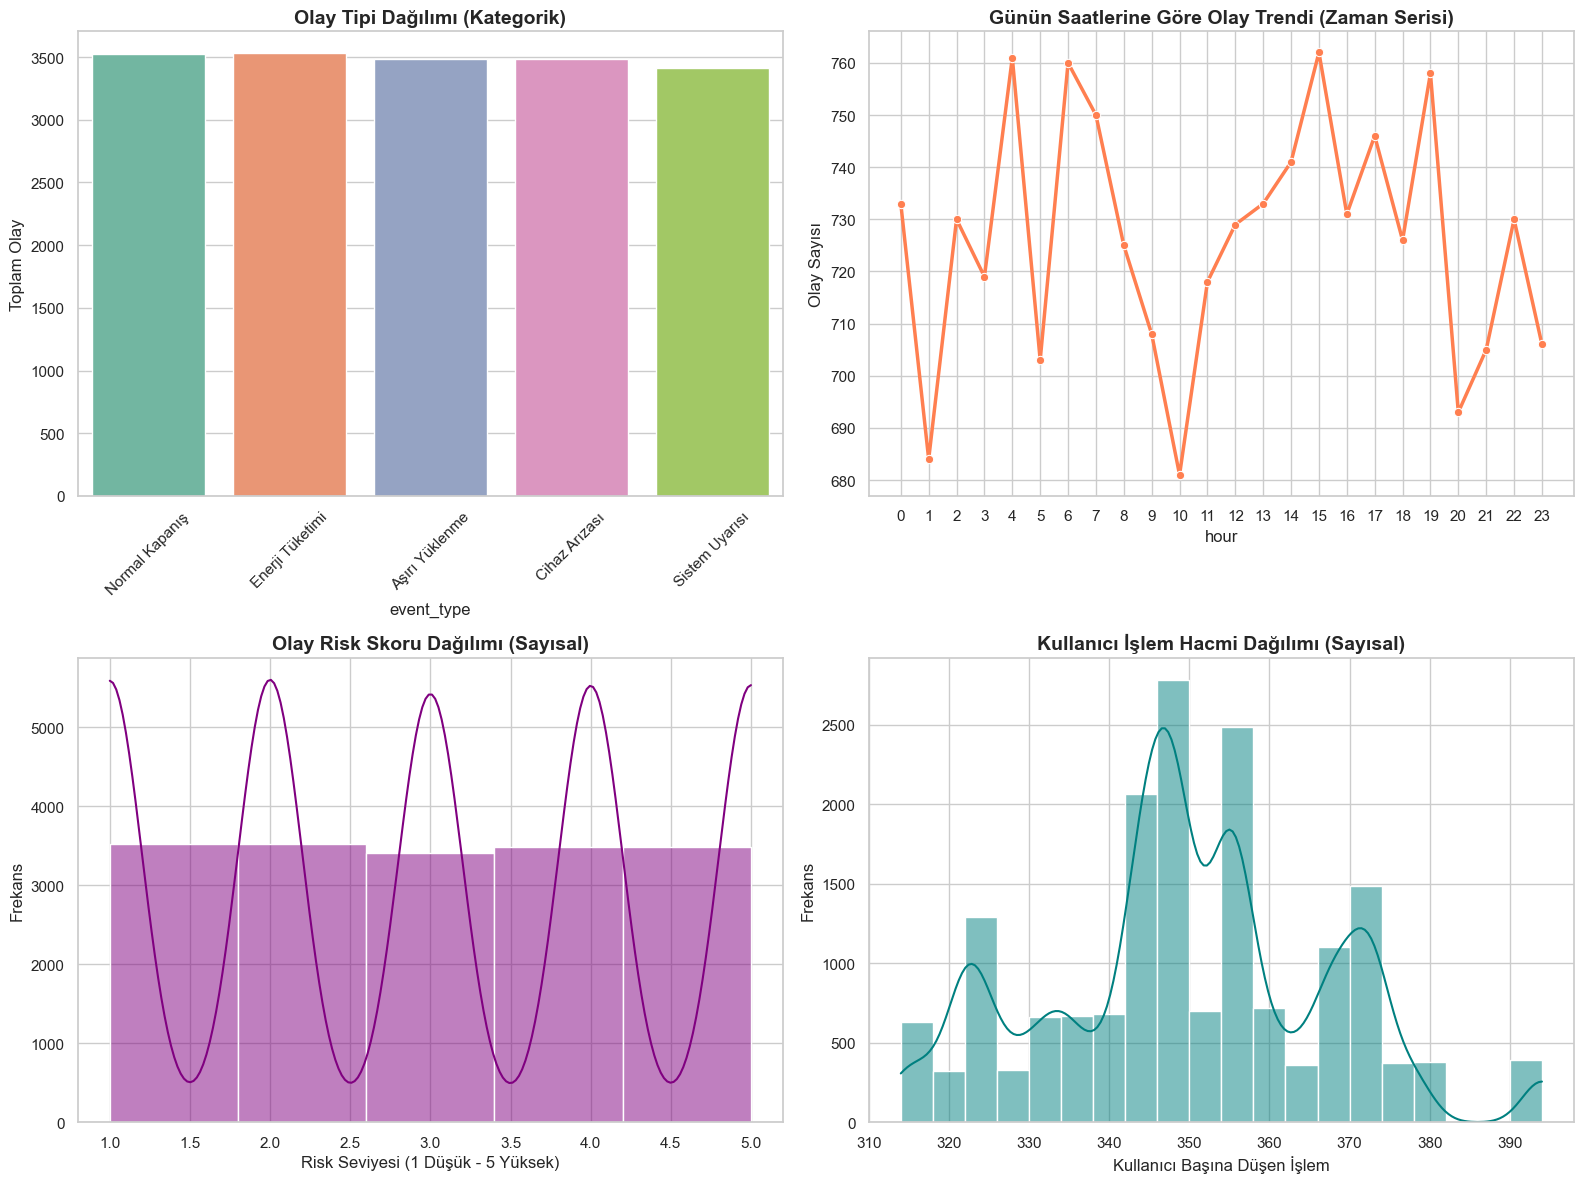

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from deltalake import DeltaTable

print("🥇 1. GOLD Veri Okunuyor...")
current_dir = os.getcwd()
gold_path = os.path.abspath(os.path.join(current_dir, "..", "data", "gold"))
df = DeltaTable(gold_path).to_pandas()

print("🧹 2. Son Temizlik Kontrolü (Güvenlik Ağı Devrede)...")
# Pandas'ın inatçı boşluklarını (NaN, pd.NA, None) türüne göre kesin olarak temizliyoruz
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(0)
    else:
        df[col] = df[col].fillna("Bilinmiyor")

print("\n--- EKSİK (NULL) DEĞER ANALİZİ ---")
eksik_degerler = df.isnull().sum()
eksik_sayisi = len(eksik_degerler[eksik_degerler > 0])

if eksik_sayisi == 0:
    print("✅ Harika! Veri setinde tek bir eksik değer bile yok. Gold katman kusursuz.")
else:
    print("❌ Hata: Hala eksik veri var:", eksik_degerler[eksik_degerler > 0])

print("\n--- 📊 KEŞİFSEL VERİ ANALİZİ (EDA) EKRANI HAZIRLANIYOR ---")
# Grafikler için profesyonel bir tema ve 2x2'lik bir tablo oluşturuyoruz
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Grafik: Kategorik Dağılım (Olay Tipleri)
sns.countplot(data=df, x='event_type', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title("Olay Tipi Dağılımı (Kategorik)", fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylabel("Toplam Olay")

# 2. Grafik: Zaman Serisi (Saatlik Trend)
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
saatlik = df.groupby('hour').size()
sns.lineplot(x=saatlik.index, y=saatlik.values, marker="o", color="coral", linewidth=2.5, ax=axes[0, 1])
axes[0, 1].set_title("Günün Saatlerine Göre Olay Trendi (Zaman Serisi)", fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(range(0, 24))
axes[0, 1].set_ylabel("Olay Sayısı")

# 3. Grafik: Sayısal Dağılım (Risk Skoru)
sns.histplot(data=df, x='event_risk_score', bins=5, kde=True, color='purple', ax=axes[1, 0])
axes[1, 0].set_title("Olay Risk Skoru Dağılımı (Sayısal)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Risk Seviyesi (1 Düşük - 5 Yüksek)")
axes[1, 0].set_ylabel("Frekans")

# 4. Grafik: Sayısal Dağılım (Kullanıcı İşlem Hacmi)
sns.histplot(data=df, x='user_event_count', bins=20, kde=True, color='teal', ax=axes[1, 1])
axes[1, 1].set_title("Kullanıcı İşlem Hacmi Dağılımı (Sayısal)", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Kullanıcı Başına Düşen İşlem")
axes[1, 1].set_ylabel("Frekans")

plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from deltalake import DeltaTable

print("🥇 1. GOLD Veri Okunuyor...")
current_dir = os.getcwd()
gold_path = os.path.abspath(os.path.join(current_dir, "..", "data", "gold"))
df = DeltaTable(gold_path).to_pandas()

print("🧹 2. Son Temizlik Kontrolü (Güvenlik Ağı Devrede)...")
# Pandas'ın inatçı boşluklarını (NaN, pd.NA, None) türüne göre kesin olarak temizliyoruz
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(0)
    else:
        df[col] = df[col].fillna("Bilinmiyor")

print("\n--- EKSİK (NULL) DEĞER ANALİZİ ---")
eksik_degerler = df.isnull().sum()
eksik_sayisi = len(eksik_degerler[eksik_degerler > 0])

if eksik_sayisi == 0:
    print("✅ Harika! Veri setinde tek bir eksik değer bile yok. Gold katman kusursuz.")
else:
    print("❌ Hata: Hala eksik veri var:", eksik_degerler[eksik_degerler > 0])

print("\n--- 📊 KEŞİFSEL VERİ ANALİZİ (EDA) EKRANI HAZIRLANIYOR ---")
# Grafikler için profesyonel bir tema ve 2x2'lik bir tablo oluşturuyoruz
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Grafik: Kategorik Dağılım (Olay Tipleri)
sns.countplot(data=df, x='event_type', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title("Olay Tipi Dağılımı (Kategorik)", fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylabel("Toplam Olay")

# 2. Grafik: Zaman Serisi (Saatlik Trend)
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
saatlik = df.groupby('hour').size()
sns.lineplot(x=saatlik.index, y=saatlik.values, marker="o", color="coral", linewidth=2.5, ax=axes[0, 1])
axes[0, 1].set_title("Günün Saatlerine Göre Olay Trendi (Zaman Serisi)", fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(range(0, 24))
axes[0, 1].set_ylabel("Olay Sayısı")

# 3. Grafik: Sayısal Dağılım (Risk Skoru)
sns.histplot(data=df, x='event_risk_score', bins=5, kde=True, color='purple', ax=axes[1, 0])
axes[1, 0].set_title("Olay Risk Skoru Dağılımı (Sayısal)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Risk Seviyesi (1 Düşük - 5 Yüksek)")
axes[1, 0].set_ylabel("Frekans")

# 4. Grafik: Sayısal Dağılım (Kullanıcı İşlem Hacmi)
sns.histplot(data=df, x='user_event_count', bins=20, kde=True, color='teal', ax=axes[1, 1])
axes[1, 1].set_title("Kullanıcı İşlem Hacmi Dağılımı (Sayısal)", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Kullanıcı Başına Düşen İşlem")
axes[1, 1].set_ylabel("Frekans")

plt.tight_layout()
plt.show()